In [ ]:
import soundfile as sf
import librosa 
import pytimbre as pt
import subprocess
import csv
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import sounddevice as sd

In [2]:
FILE_PATH = r"corpus\metro_sample_2.wav"

In [74]:
audio, sr = sf.read(FILE_PATH) #multi channel output
audio.shape, sr

((4499456, 2), 48000)

48kHz sr, so 48k samples per second. So, a 1 ms or 10 ms grain will contain 48 samples or 480 samples respectively

### 1. The analysis of the audio and its grains

In [18]:
y,sr = librosa.load(FILE_PATH, sr=48000)

In [ ]:
y.shape, sr

((4499456,), 48000)

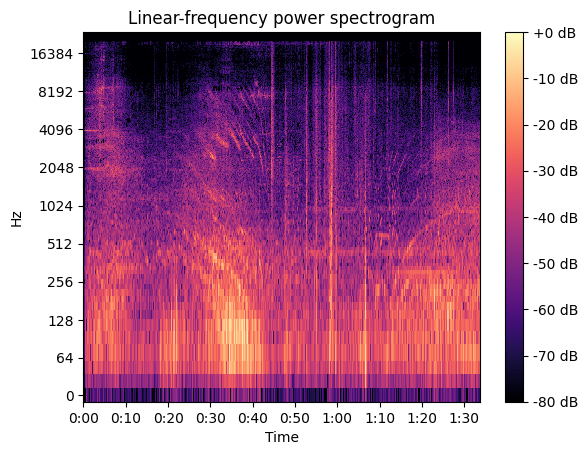

In [5]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
fig, ax = plt.subplots()
img = librosa.display.specshow(data=D,y_axis='log', x_axis='time', sr=sr, ax=ax)
ax.set(title='Linear-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")


Using flucoma's fluid-noveltyslicer CLI tools to extract novel slice indices

In [19]:
import csv
with open('indices.csv', 'r') as f:
    slice_indices = np.array([int(i) for i in list(csv.reader(f))[0]])
slice_indices

def cli_flucoma_features(exe, input_file, output_file):
    """ 
    if the exe returns features, such as pitch or loudness information, return this. 
    Otherwise just writes the file according to the exe process
    """
    command = [
        exe,
        "-source", input_file,
        "-features", output_file
    ]
    try:
        result = subprocess.run(
            command, 
            check=True,          # Raises CalledProcessError if the exit code is non-zero
            capture_output=True, # Captures stdout and stderr
            text=True            # Returns output as strings instead of bytes
        )
        # print("Command Output:\n", result.stdout)

    except subprocess.CalledProcessError as e:
        print(f"An error occurred while running fluid-noveltyslice: {e}")
        print("Error details:", e.stderr)
    if "csv" in output_file[:-4]:
        with open(output_file, 'w') as f:
            features = np.array([int(i) for i in list(csv.reader(f))[0]])   
        return features

In [17]:
r= cli_flucoma_features("fluid-pitch", "output\output_1.wav", "pitch_test.csv")

Command Output:
   8%
 17%
 26%
 39%
 49%
 56%
 71%
 85%
 98%
100%



Extracting the MFCC coefficients for each grain. Each grain is now 480 samples, i.e. 100 ms long (at most)

In [39]:
import csv
with open('indices.csv', 'r') as f:
    slice_indices = np.array([int(i) for i in list(csv.reader(f))[0]])
slice_indices

array([   9216,  410112,  869888,  873984,  875520,  882176,  914432,
        921600,  923648, 1033216, 1047552, 1142784, 1552384, 1637888,
       1694720, 1743360, 1843712, 2019840, 2326016, 2329600, 2403328,
       2463232, 2490880, 2497024, 2534912, 2763264, 2765824, 2781696,
       2816512, 2830848, 2839552, 2847744, 2902016, 2916864, 2966016,
       2979840, 3047424, 3086336, 3101696, 3111936, 3130880, 3319808,
       3446784, 3487232, 3574784, 3585536, 3597312, 3623936, 3870208,
       4007424, 4011008, 4040192, 4048384, 4128256, 4162048, 4166656,
       4174336, 4270592, 4346880, 4405760, 4422144])

if sr is 48kHz, if I want 480 max, then, I can do index:index+480

In [75]:
grains = []
audio_mono = np.mean(audio, axis=1)
audio_len = len(audio_mono)
for index in slice_indices:
    grain_end = index+480
    if grain_end > audio_len:
        grain_end = audio_len
    grains.append((index, grain_end))
grains

[(np.int64(9216), np.int64(9696)),
 (np.int64(410112), np.int64(410592)),
 (np.int64(869888), np.int64(870368)),
 (np.int64(873984), np.int64(874464)),
 (np.int64(875520), np.int64(876000)),
 (np.int64(882176), np.int64(882656)),
 (np.int64(914432), np.int64(914912)),
 (np.int64(921600), np.int64(922080)),
 (np.int64(923648), np.int64(924128)),
 (np.int64(1033216), np.int64(1033696)),
 (np.int64(1047552), np.int64(1048032)),
 (np.int64(1142784), np.int64(1143264)),
 (np.int64(1552384), np.int64(1552864)),
 (np.int64(1637888), np.int64(1638368)),
 (np.int64(1694720), np.int64(1695200)),
 (np.int64(1743360), np.int64(1743840)),
 (np.int64(1843712), np.int64(1844192)),
 (np.int64(2019840), np.int64(2020320)),
 (np.int64(2326016), np.int64(2326496)),
 (np.int64(2329600), np.int64(2330080)),
 (np.int64(2403328), np.int64(2403808)),
 (np.int64(2463232), np.int64(2463712)),
 (np.int64(2490880), np.int64(2491360)),
 (np.int64(2497024), np.int64(2497504)),
 (np.int64(2534912), np.int64(2535392)

In [47]:
for g in grains:
    g[0] + 1
    break

In [82]:
grains_mfccs = []
for grain in grains:
    s, e = grain
    data = audio_mono[s:e]
    grain_mfcc = librosa.feature.mfcc(y=audio_mono[s:e], sr=sr)
    grains_mfccs.append(grain_mfcc)




Plotting centroid x rolloff

In [105]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [113]:
descriptors = []
for grain in grains:
    s, e = grain
    data = audio_mono[s:e]
    spectral_centroid = librosa.feature.spectral_centroid(y=data, sr=sr)
    spectroll_rolloff = librosa.feature.spectral_rolloff(y=data, sr=sr)
    descr = float(spectral_centroid), float(spectroll_rolloff)
    descriptors.append(descr)


c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=480
  warnings.warn(
C:\Users\hippo\AppData\Local\Temp\ipykernel_16924\4073138305.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  descr = float(spectral_centroid), float(spectroll_rolloff)


In [4]:
from sklearn.preprocessing import normalize

In [131]:
arr = np.array(descriptors)
arr_norm = normalize(arr, norm="l2")
arr, arr_norm

(array([[    0.        ,     0.        ],
        [ 4055.25414681,  8578.125     ],
        [ 2897.04396913,  5039.0625    ],
        [ 2841.61467172,  6023.4375    ],
        [ 3291.60832045,  7101.5625    ],
        [ 4093.61481402, 10851.5625    ],
        [ 5028.28578968, 19125.        ],
        [ 2002.66627129,  2179.6875    ],
        [ 5037.52222558, 14695.3125    ],
        [ 1879.943212  ,  2414.0625    ],
        [ 3855.53392064,  9164.0625    ],
        [ 2825.75216016,  4289.0625    ],
        [ 4454.24740674, 10945.3125    ],
        [ 4284.49412487, 10992.1875    ],
        [ 2268.31301221,  4007.8125    ],
        [ 2263.92277142,  3773.4375    ],
        [ 4084.00838057,  8718.75      ],
        [ 4981.40668691,  9210.9375    ],
        [ 3689.37566123,  7921.875     ],
        [ 4040.72910504,  9539.0625    ],
        [ 6838.33499362, 19664.0625    ],
        [ 4146.94706171,  9445.3125    ],
        [ 4885.36823558, 17132.8125    ],
        [ 4848.61004536, 11273.437

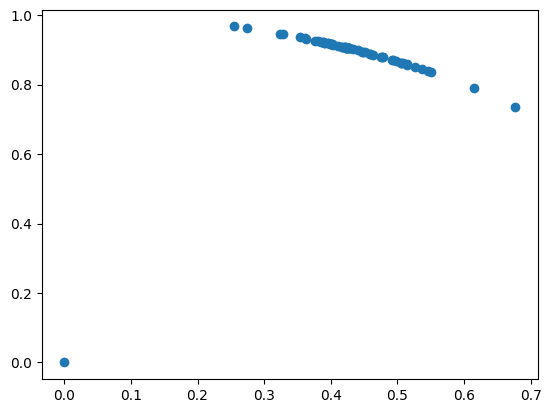

In [132]:
plt.scatter(arr_norm[:, 0], arr_norm[:, 1])

we reduce the 20 coeffs down to two values using UMAP and display the grains dispersed across time

In [ ]:
import umap

In [58]:
reducer = umap.UMAP()

In [89]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import matplotlib.pyplot as plt

In [93]:
# Each (20, 1) becomes a row in a (n, 20) matrix
data_matrix = np.stack([mfcc.flatten() for mfcc in grains_mfccs]) 
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data_matrix)

reducer = UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
embedding = reducer.fit_transform(data_matrix)

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


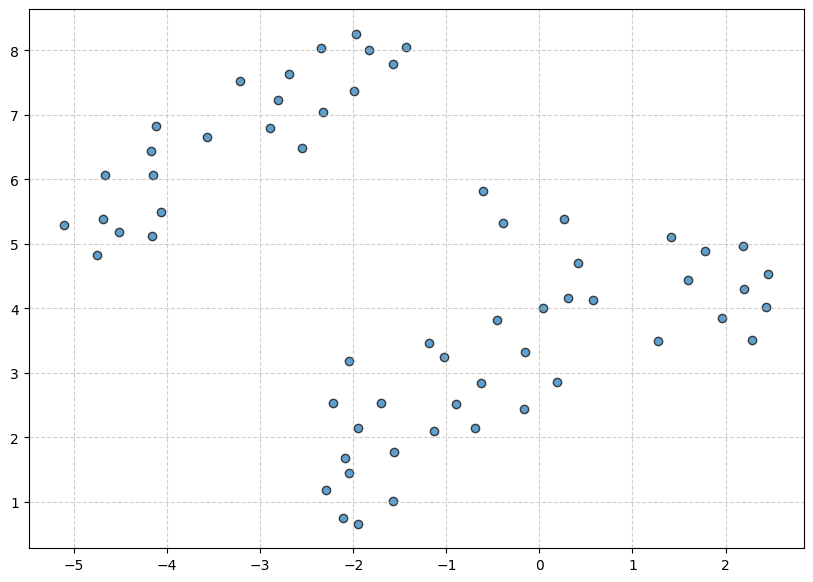

In [95]:
plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], edgecolors='k', alpha=0.7)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
import audioflux as af
from audioflux.type import SpectralDataType, SpectralFilterBankScaleType


In [26]:
np.random.seed(31)

In [40]:
slice_indices=None
density = 200
y, sr = sf.read(FILE_PATH)
output_buffer = np.zeros(len(y)) #output buffer 

if y.ndim > 1:
    y = np.mean(y, axis=1) # make mono if not alrdy
audio_len = len(y)

n_grains = audio_len//480

if not slice_indices:
    slice_indices = np.array(
        [i*480 for i in range(n_grains)]
    )
    # slice_indices = np.random.choice(slice_indices, 20, replace=False)

pos_chunks = audio_len//density

grains_descriptors = []
for index in slice_indices:
    grain_end = index+np.random.choice(list(range(48,4800))) # 1ms to 100ms
    if grain_end > audio_len:
        grain_end = audio_len
    s, e = index, grain_end
    grain = y[s: e]
    grain = grain * np.hanning(len(grain))
    # print(grain.shape[-1])
    bft_obj = af.BFT(num=256//2**5, samplate=sr, radix2_exp=4,
                 data_type=SpectralDataType.MAG,
                 scale_type=SpectralFilterBankScaleType.LINEAR)
    spec_arr = bft_obj.bft(grain)
    spec_arr = np.abs(spec_arr)
    
    # Create Spectral object and extract spectral feature
    spectral_obj = af.Spectral(num=bft_obj.num,
                            fre_band_arr=bft_obj.get_fre_band_arr())
    spectral_obj.set_time_length(spec_arr.shape[-1])

    flatness_arr = spectral_obj.flatness(spec_arr)
    novelty_arr = spectral_obj.novelty(spec_arr)
    entropy_arr = spectral_obj.entropy(spec_arr)
    rms_arr = spectral_obj.rms(spec_arr)
    slope_arr = spectral_obj.slope(spec_arr)

    flatness = np.mean(flatness_arr)
    slope = np.mean(slope_arr)
    entropy = np.mean(entropy_arr)
    rms = np.mean(rms_arr)
    descriptors = {
        "flatness" : float(flatness),
        'slope': float(slope),
        # 'entropy': entropy,
        'rms': float(rms)
    }
    grains_descriptors.append(descriptors)
    # compute stat mean of each of these 
    
    # TODO: add hanning window 
    # sd.play(grain,sr)
    # sd.wait




In [41]:
import json
with open("grains_descriptors.json", "w") as f:
    grains_descriptors = grains_descriptors
    json.dump(grains_descriptors, f,indent =4)

In [44]:
descriptors_arr = np.array([[dic[key] for dic in grains_descriptors] for key in list(grains_descriptors[0].keys())])
descriptors_arr

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.36645123e-01,  1.36772409e-01,  1.48662060e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -8.13575662e-06, -8.50131619e-06, -7.93106210e-06],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.33139859e-02,  3.47895212e-02,  3.27170826e-02]],
      shape=(3, 9373))

In [ ]:
descriptors_arr[0]


array([0., 0., 0.])

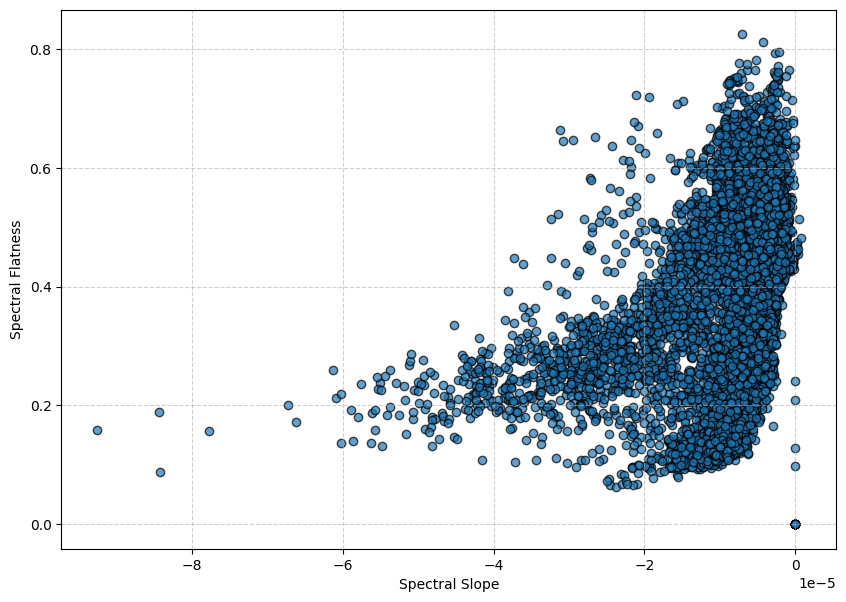

In [52]:
plt.figure(figsize=(10, 7))
plt.scatter(descriptors_arr[1], descriptors_arr[0], edgecolors='k', alpha=0.7)
plt.ylabel("Spectral Flatness")
plt.xlabel("Spectral Slope")
# plt.ylabel("Rms")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. making the granular synth, basic architecture

In [5]:
import csv
with open('indices.csv', 'r') as f:
    slice_indices = np.array([int(i) for i in list(csv.reader(f))[0]])
slice_indices

array([   9216,  410112,  869888,  873984,  875520,  882176,  914432,
        921600,  923648, 1033216, 1047552, 1142784, 1552384, 1637888,
       1694720, 1743360, 1843712, 2019840, 2326016, 2329600, 2403328,
       2463232, 2490880, 2497024, 2534912, 2763264, 2765824, 2781696,
       2816512, 2830848, 2839552, 2847744, 2902016, 2916864, 2966016,
       2979840, 3047424, 3086336, 3101696, 3111936, 3130880, 3319808,
       3446784, 3487232, 3574784, 3585536, 3597312, 3623936, 3870208,
       4007424, 4011008, 4040192, 4048384, 4128256, 4162048, 4166656,
       4174336, 4270592, 4346880, 4405760, 4422144])

In [3]:
np.random.seed(11111)

In [8]:
def granular_synthesizer(input_audio, output_audio, slice_indices, density, pos_shift:int):
    """ 
    
    density: the number of grains per second, i.e. frequency Hz
        example, if 8 grains per second, then evenly distributed 
        1 second here is 48000 samples. Then, 8 grains interspersed over 48k samples
    """


    y, sr = sf.read(input_audio)
    output_buffer = np.zeros(len(y)) #output buffer 

    if y.ndim > 1:
        y = np.mean(y, axis=1) # make mono if not alrdy
    audio_len = len(y)

    n_grains = audio_len//480
    
    if not slice_indices:
        slice_indices = np.array(
            [i*480 for i in range(n_grains)]
        )
        slice_indices = np.random.choice(slice_indices, 20, replace=False)

    pos_chunks = audio_len//density
    for index in slice_indices:
        grain_end = index+np.random.choice(list(range(48,4800)))
        if grain_end > audio_len:
            grain_end = audio_len
        s, e = index, grain_end
        grain = y[s: e]
        grain = grain * np.hanning(len(grain))
        # TODO: add hanning window 
        sd.play(grain,sr)
        sd.wait
        
        for i in range(density):
            pos_s = (pos_chunks*(i+1)) + np.random.choice(list(range(-pos_shift, pos_shift)))
            pos_s = np.clip(pos_s, a_min=0, a_max=audio_len-1)
            pos_e = np.clip(pos_s+ (e-s), a_min=0, a_max=audio_len-1)
            if len(grain) > pos_e-pos_s:
                grain = grain[:pos_e-pos_s]
            output_buffer[pos_s: pos_e] += grain
    # output_norm = normalize(output_buffer, norm="l1")
        

    # TODO: add the grains in the buffer at some density, and some (stochastic) spacing, 
    # TODO: then, layer them and normalize the final output.  
    sf.write(output_audio, output_buffer,sr)
    
granular_synthesizer(
    input_audio=FILE_PATH,
    output_audio="output/output_4.wav",
    slice_indices=None,
    density=1000,
    pos_shift=300
)

In [26]:
import sounddevice as sd

In [33]:
def play_grains(input_audio, output_audio, slice_indices, density, pos_shift:int):
    """ 
    
    density: the number of grains per second, i.e. frequency Hz
    example, if 8 grains per second, then evenly distributed 
    1 second here is 48000 samples. Then, 8 grains interspersed over 48k samples
    """
    y, sr = sf.read(input_audio)
    output_buffer = np.zeros(len(y)) #output buffer 

    if y.ndim > 1:\
        y = np.mean(y, axis=1) # make mono if not alrdy
    audio_len = len(y)
    pos_chunks = audio_len//density
    for index in slice_indices:
        grain_end = index+np.random.choice(list(range(48,480)))
        if grain_end > audio_len:
            grain_end = audio_len
        s, e = index, grain_end
        new_data = y[s: e]
        sd.play(new_data,sr)
        sd.wait
        
    # output_norm = normalize(output_buffer, norm="l1")
        

    # TODO: add the grains in the buffer at some density, and some (stochastic) spacing, 
    # TODO: then, layer them and normalize the final output.  
    # sf.write(output_audio, output_buffer,sr)
    
granular_synthesizer(
    input_audio=FILE_PATH,
    output_audio="output/output_1.wav",
    slice_indices=slice_indices,
    density=3000,
    pos_shift=300
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [29]:
y, sr = sf.read(FILE_PATH)

if y.ndim > 1:
    y = np.mean(y, axis=1) # make mono if not alrdy
audio_len = len(y)
for index in slice_indices:
    grain_end = index+np.random.choice(list(range(48,480)))
    if grain_end > audio_len:
        grain_end = audio_len
    s, e = index, grain_end
    new_data = y[s: e]
    sd.play(new_data,sr)
    sd.wait

In [ ]:
sf.write

In [17]:
granular_synthesizer(input_audio=FILE_PATH, output_audio="output/output_1.wav")

(4499456, 2)

In [ ]:
FILE_PATH = r"corpus\metro_sample.wav"